
# Local search - Flowshop problem

This notebook offers a hands-on approach to addressing the flowshop problem, emphasizing the application of various established local search algorithms for effective problem-solving.

### Table of content

- [Recuit Simulé](#Simulated-annealing-Recuit-simulé)
- [Tabu Search](#Tabu-Search)
- [VNS](#VNS)
- [Tests](#Tests)


### References
- [Benchmarks for Basic Scheduling Problems](http://mistic.heig-vd.ch/taillard/articles.dir/Taillard1993EJOR.pdf)
- [Introduction to Hill Climbing](https://www.geeksforgeeks.org/introduction-hill-climbing-artificial-intelligence/)
- [tabu search paper](https://www.sciencedirect.com/science/article/abs/pii/S0377221797001367)

In [ ]:
import numpy as np
import matplotlib as plt
import itertools
import time
import pandas as pd
import math
import random
from collections import deque
from itertools import combinations

In [ ]:
def evaluate_sequence(sequence, processing_times):
    _, num_machines = processing_times.shape
    num_jobs = len(sequence)
    completion_times = np.zeros((num_jobs, num_machines))

    # Calculate the completion times for the first machine
    completion_times[0][0] = processing_times[sequence[0]][0]
    for i in range(1, num_jobs):
        completion_times[i][0] = completion_times[i-1][0] + processing_times[sequence[i]][0]

    # Calculate the completion times for the remaining machines
    for j in range(1, num_machines):
        completion_times[0][j] = completion_times[0][j-1] + processing_times[sequence[0]][j]
        for i in range(1, num_jobs):
            completion_times[i][j] = max(completion_times[i-1][j], completion_times[i][j-1]) + processing_times[sequence[i]][j]

    # Return the total completion time, which is the completion time of the last job in the last machine
    return completion_times[num_jobs-1][num_machines-1]

In [ ]:
# Instance Aléatoire pour des tests
rnd_data = np.random.randint(size=(15,10), low=5, high=120)
permutation = np.random.permutation(10).tolist()
print(rnd_data, "\n")
print('Initial solution:', permutation, "\n")

Cmax = evaluate_sequence(permutation, rnd_data)
print(f'Makespan: {Cmax}')

[[ 92  45  50  64  10  55  47 106  69  61]
 [112  55 110  18  72 119  28  19  79  26]
 [ 54  70   6   8   9  58  11  59  88  61]
 [ 28  84  78  88  89  33  77  61   8  78]
 [107  11  45  28 116  53  91 106  46  72]
 [  8 106 100 119 106 101  71   7 101  21]
 [ 49  54  84  54  85  96  57  10  82  71]
 [119 101 118  14  90  34   6   5  90  99]
 [ 29 117  51   8  80  63 114  16  76  27]
 [ 88   8  14  69  75  74  70 109  81  30]
 [ 71 109  78  24  61  32   8  68  61  43]
 [ 23  80  69  80 117  60  53 106  59  36]
 [ 72  65  34  48  32 112 112  64  95 101]
 [ 49 100  77  20  28  66  19  20  96  87]
 [106  73  22  32  55  99  66 111  70   5]] 

Initial solution: [8, 1, 4, 3, 0, 6, 7, 5, 2, 9] 

Makespan: 1603.0


In [ ]:
def swap(solution, i, k):
    temp = solution[k]
    solution[k] = solution[i]
    solution[i] = temp
    return solution

In [ ]:
def random_swap(solution, processing_times):
    i = np.random.choice(list(solution))
    k = np.random.choice(list(solution))
    # Generating two different random positions
    while (i == k):
        k = np.random.choice(list(solution))
    # Switch between job i and job k in the given sequence
    neighbor = solution.copy()
    return swap(neighbor, i, k), evaluate_sequence(neighbor, processing_times)

In [ ]:
def swap_jobs(permutation):
    idx1, idx2 = random.sample(range(len(permutation)), 2)
    permutation[idx1], permutation[idx2] = permutation[idx2], permutation[idx1]


In [ ]:
def best_first_swap(solution, processing_times):
    # This function will take a solution, and return the first best solution.
    # The first solution that is better then the current one 'solution' in args.
    num_jobs = len(solution)
    best_cmax = evaluate_sequence(solution, processing_times)
    best_neighbor = solution.copy()
    for k1 in range(num_jobs):
        for k2 in range(k1+1, num_jobs):
            neighbor = solution.copy()
            neighbor = swap(neighbor,k1,k2)
            cmax = evaluate_sequence(neighbor, processing_times)
            if cmax < best_cmax:
                best_neighbor = neighbor
                best_cmax = cmax
                return best_neighbor, best_cmax
    return best_neighbor, best_cmax

In [ ]:
def best_swap(solution, processing_times):
    # This function will take a solution, and return its best neighbor solution.
    num_jobs = len(solution)
    best_cmax = np.Infinity
    for k1 in range(num_jobs):
        for k2 in range(k1+1, num_jobs):
            neighbor = solution.copy()
            neighbor = swap(neighbor,k1,k2)
            cmax = evaluate_sequence(neighbor, processing_times)
            if cmax < best_cmax:
                best_neighbor = neighbor
                best_cmax = cmax
    return best_neighbor, best_cmax

In [ ]:
def best_swaps(solution, processing_times):
    # This function will take a solution, and return a list that contains all solutions that are better than it.
    num_jobs = len(solution)
    cmax = evaluate_sequence(solution, processing_times)
    bests = []
    for k1 in range(num_jobs):
        for k2 in range(k1+1, num_jobs):
            neighbor = solution.copy()
            swap(neighbor,k1,k2)
            neighbor_cmax = evaluate_sequence(neighbor, processing_times)
            if neighbor_cmax < cmax:
                bests.append((neighbor_cmax, neighbor))
    bests.sort(key=lambda x: x[0])
    return bests

In [ ]:
def random_inversion(permutation,processing_times):
    idx1, idx2 = sorted(random.sample(range(len(permutation)), 2))
    permutation[idx1:idx2+1] = reversed(permutation[idx1:idx2+1])
    return permutation, evaluate_sequence(permutation, processing_times)


# Hill climbing

## Simple Hill climbing

It evaluates adjacent nodes and chooses the initial adjacent node that optimizes the current cost as the subsequent node.

---



In [ ]:
def simple_hill_climbing(solution, processing_times, nb_iter=10000):
    x = solution
    cmax = evaluate_sequence(solution, processing_times)
    iterations = 0
    while iterations < nb_iter:
        best_neighbor, best_cmax  = best_first_swap(x, processing_times)
        if best_cmax == cmax:
            return best_neighbor, best_cmax, iterations
        x = best_neighbor
        cmax = best_cmax
        iterations += 1
    return x, cmax, iterations

In [ ]:
print("Initial solution:", permutation)
print("Makespan:", Cmax)

start_time = time.time()
best_solution, best_cmax, nb_iterations = simple_hill_climbing(permutation, rnd_data)
elapsed_time = time.time() - start_time

print("\nGenerated solution:", best_solution)
print("Makespan:", best_cmax)
print("\nElapsed time:", elapsed_time, "seconds")

Initial solution: [8, 1, 4, 3, 0, 6, 7, 5, 2, 9]
Makespan: 1603.0

Generated solution: [5, 2, 0, 6, 9, 3, 7, 4, 8, 1]
Makespan: 1415.0

Elapsed time: 0.019359111785888672 seconds


## Steepest Ascent Hill climbing

It iteratively evaluates neighboring nodes and chooses the optimal neighboring node that minimizes the current cost as the next node.

In [ ]:
def steepest_ascent_hill_climbing(solution, processing_times, nb_iter=1000):
    x = solution
    cmax = evaluate_sequence(solution, processing_times)
    iterations = 0
    while iterations < nb_iter:
        best_neighbor, best_cmax = best_swap(solution, processing_times)
        if best_cmax > cmax:
            return x, cmax
        else:
            x = best_neighbor
            cmax = best_cmax
            iterations += 1
    return best_neighbor, best_cmax, iterations

In [ ]:
print("Initial solution:", permutation)
print("Makespan:", Cmax)

start_time = time.time()
best_solution, best_cmax, nb_iterations = steepest_ascent_hill_climbing(permutation, rnd_data)
elapsed_time = time.time() - start_time

print("\nGenerated solution:", best_solution)
print("Makespan:", best_cmax)
print("Number of iterations:", nb_iterations)
print("\nElapsed time:", elapsed_time, "seconds")

Initial solution: [8, 1, 4, 3, 0, 6, 7, 5, 2, 9]
Makespan: 1603.0



Generated solution: [8, 1, 4, 3, 0, 6, 5, 7, 2, 9]
Makespan: 1478.0
Number of iterations: 1000

Elapsed time: 3.10341215133667 seconds


## Stochastic Hill climbing

From the set of generated neighbor states that outperform the current state, it randomly selects a state (or follows a probability function) to determine the next step.

In [ ]:
def stochastic_hill_climbing(solution, processing_times, nb_iter=1000):
    x = solution
    cmax = evaluate_sequence(solution, processing_times)
    iterations = 0
    while iterations < nb_iter:
        best_neighbours  = best_swaps(x, processing_times)
        if len(best_neighbours) == 0:
            return x, cmax, iterations
        i = random.randint(0,len(best_neighbours) - 1)
        best_cmax, best_neighbor = best_neighbours[i]
        if best_cmax > cmax:
            return x, cmax, iterations
        x = best_neighbor
        cmax = best_cmax
        iterations += 1
    return best_neighbor, best_cmax, iterations

In [ ]:
print("Initial solution:", permutation)
print("Makespan:", Cmax)

start_time = time.time()
best_solution, best_cmax, nb_iterations = stochastic_hill_climbing(permutation, rnd_data)
elapsed_time = time.time() - start_time

print("\nGenerated solution:", best_solution)
print("Makespan:", best_cmax)
print("Number of iterations:", nb_iterations)
print("\nElapsed time:", elapsed_time, "seconds")

Initial solution: [8, 1, 4, 3, 0, 6, 7, 5, 2, 9]
Makespan: 1603.0

Generated solution: [8, 1, 0, 3, 2, 6, 4, 7, 9, 5]
Makespan: 1449.0
Number of iterations: 7

Elapsed time: 0.026775121688842773 seconds


# Simulated annealing- recuit simulé

In [ ]:
def get_neighbor(solution, processing_times, method="random_swap"):
    # Swapping methods
    if method == "random_swap":
        neighbor, cost = random_swap(solution, processing_times)
    elif method == "best_swap":
        neighbor, cost = best_swap(solution, processing_times)
    elif method == "best_first_swap":
        neighbor, cost = best_first_swap(solution, processing_times)
    # Insertion methods
    elif method == "random_insertion":
        neighbor, cost = random_insertion(solution, processing_times)
    elif method == "best_edge_insertion":
        neighbor, cost = best_edge_insertion(solution, processing_times)
    elif method == "best_insertion":
        neighbor, cost = best_insertion(solution, processing_times)
    # inversion method
    elif method=="random_inversion":
        neighbor,cost = random_inversion(solution,processing_times)


    return neighbor, cost


In [ ]:
def simulated_annealing(initial_solution, processing_times, method="random_swap", initial_temp=1000, final_temp=1, alpha=0.9):
    current_temp = initial_temp
    current_solution = initial_solution.copy()
    current_cost = evaluate_sequence(initial_solution, processing_times)
    while current_temp > final_temp:
        neighbor, neighbor_cost  = get_neighbor(current_solution, processing_times, method)
        cost_diff = current_cost - neighbor_cost
        if cost_diff > 0:
            current_solution = neighbor
            current_cost = neighbor_cost
        else:
            if random.uniform(0, 1) < math.exp(-cost_diff / current_temp):
                solution = neighbor
        current_temp *= alpha
    return current_solution, current_cost

# Tabu Search

In [ ]:
def order_jobs_in_descending_order_of_total_completion_time(processing_times):
    total_completion_time = processing_times.sum(axis=1)
    return np.argsort(total_completion_time, axis=0).tolist()

def insertion(sequence, position, value):
    new_seq = sequence[:]
    new_seq.insert(position, value)
    return new_seq

def evaluate_sequence(sequence, processing_times):
    _, num_machines = processing_times.shape
    num_jobs = len(sequence)

    # Check if the sequence is empty
    if num_jobs == 0:
        # Return a default value (you may choose 0 or another suitable value)
        return 0

    completion_times = np.zeros((num_jobs, num_machines))

    # Calculate the completion times for the first machine
    completion_times[0][0] = processing_times[sequence[0]][0]
    for i in range(1, num_jobs):
        completion_times[i][0] = completion_times[i-1][0] + processing_times[sequence[i]][0]

    # Calculate the completion times for the remaining machines
    for j in range(1, num_machines):
        completion_times[0][j] = completion_times[0][j-1] + processing_times[sequence[0]][j]
        for i in range(1, num_jobs):
            completion_times[i][j] = max(completion_times[i-1][j], completion_times[i][j-1]) + processing_times[sequence[i]][j]

    # Return the total completion time, which is the completion time of the last job in the last machine
    return completion_times[num_jobs-1][num_machines-1]

class TabuList:
    def __init__(self, max_size):
        self.max_size = max_size
        self.moves = []

    def add(self, move):
        if len(self.moves) >= self.max_size:
            self.moves.pop(0)
        self.moves.append(move)

    def is_tabu(self, move):
        return move in self.moves


import random

def generate_neighbor(sequence):
    neighbor_type = random.choice([1, 2,3])

    if neighbor_type == 1:#sap
        return swap_neighbor(sequence)
    elif neighbor_type == 2:#insert 1 individual job
        return insert_neighbor(sequence)
    elif neighbor_type == 3:#insert a block of length k
        return block_insert_neighbor(sequence)

def swap_neighbor(sequence):
    # Select random positions i and j
    i, j = random.sample(range(len(sequence)), 2)
    neighbor = sequence[:]
    neighbor[i], neighbor[j] = neighbor[j], neighbor[i]
    return neighbor

def insert_neighbor(sequence):
    # Select random positions i and j
    i, j = random.sample(range(len(sequence)), 2)
    neighbor = sequence[:]
    job_to_insert = neighbor.pop(i)
    neighbor.insert(j, job_to_insert)
    return neighbor

def block_insert_neighbor(sequence):
    # Select random positions i, j, and k
    i = random.randint(0, len(sequence) - 1)
    j = random.randint(0, len(sequence))
    k = random.randint(1, len(sequence) - i)
    neighbor = sequence[:]
    block_to_insert = neighbor[i:i+k]
    neighbor = neighbor[:j] + block_to_insert + neighbor[j:]
    return neighbor

def generate_candidate_list(sequence):
    n = len(sequence)
    candidate_list_size = 2 * n
    candidate_list = [generate_neighbor(sequence) for _ in range(candidate_list_size)]
    return candidate_list

def select_best_neighbor(processing_times,candidate_list, current_solution, tabu_list,best_makespan):
    best_neighbor = None

    # Iterate through the candidate list
    for neighbor in candidate_list:
        # Calculate makespan for the neighbor
        neighbor_makespan = evaluate_sequence(neighbor, processing_times)
        # Check if the neighbor is not tabu and improves the current solution
        if neighbor_makespan < best_makespan and not tabu_list.is_tabu(neighbor):
            best_neighbor = neighbor
            best_makespan = neighbor_makespan

    # If no improving move is found, examine the whole candidate list
    if best_neighbor is None:
        for neighbor in candidate_list:
            neighbor_makespan = evaluate_sequence(neighbor, processing_times)
            if neighbor_makespan < best_makespan:
                best_neighbor = neighbor
                best_makespan = neighbor_makespan

    return best_neighbor



def recherche_tabou(processing_times,s0,tabu_size, max_it, max_it_stagn):
    best_cmax = evaluate_sequence(s0, processing_times)
    best_solution = s0
    tabu_list = TabuList(tabu_size)
    stagnation_count = 0  # Counter to track stagnation iterations

    for i in range(max_it):
        candidate_list = generate_candidate_list(s0)
        best_neighbor = select_best_neighbor(processing_times, candidate_list, s0, tabu_list, best_cmax)

        # Check if there is no improving move
        if best_neighbor is None:
            stagnation_count += 1
            if stagnation_count >= max_it_stagn:
                break  # Terminate if stagnation persists
        else:
            stagnation_count = 0  # Reset stagnation counter
            # Update the current solution
            s0 = best_neighbor
            # Update the makespan of the best solution if a better solution is found
            current_makespan = evaluate_sequence(s0, processing_times)
            if current_makespan < best_cmax:
                best_solution = s0
                best_cmax = current_makespan
            # Update the tabu list
            tabu_list.add(s0)

    return best_solution, best_cmax , i




# VNS

In [ ]:
#Perturbation
def shake(solution, k):
    n = len(solution)
    indices = random.sample(range(n), min(k, n-1))
    indices.sort()
    neighbor = solution.copy()
    for i in indices:
        j = (i+k) % n
        neighbor[i], neighbor[j] = neighbor[j], neighbor[i]
    return neighbor


- Apply the "shake" perturbation to generate a random neighbor.
- Iterate through neighbors to find the best local solution.
- If the best solution found in the neighborhood is better than the current solution,
- update the current solution and reset the search radius.

In [ ]:
def get_neighbor(solution, processing_times, method="random_swap"):
    # Swapping methods
    if method == "random_swap":
        neighbor, cost = random_swap(solution, processing_times)
    elif method == "best_swap":
        neighbor, cost = best_swap(solution, processing_times)
    elif method == "best_first_swap":
        neighbor, cost = best_first_swap(solution, processing_times)
    # Randomly pick a method of generating neighbors.
    else:
        i = random.randint(0, 2)
        if i == 0:
            neighbor, cost = random_swap(solution, processing_times)
        elif i == 1:
            neighbor, cost = best_swap(solution, processing_times)
        elif i == 2:
            neighbor, cost = best_first_swap(solution, processing_times)
    return neighbor, cost

In [ ]:
def vns(sol_init, processing_times, max_iterations, k_max):
    num_jobs = len(sol_init)
    current_solution = sol_init
    current_cost = evaluate_sequence(current_solution, processing_times)
    k = 1
    iteration = 0
    while iteration < max_iterations:
        best_neighbor_solution = shake(current_solution, k)
        best_neighbor_cost = evaluate_sequence(best_neighbor_solution, processing_times)
        for l in range(1, k_max+1):
            neighbor, neighbor_cost  = get_neighbor(current_solution, processing_times, method="random")
            if (neighbor_cost < best_neighbor_cost):
                best_neighbor_solution = neighbor
                best_neighbor_cost = neighbor_cost
        if ( best_neighbor_cost < current_cost ):
            current_solution = best_neighbor_solution
            current_cost = best_neighbor_cost
            k = 1
        else:
            k += 1
        iteration += 1
    return current_solution, current_cost

# Tests

## Heuristics
### Pour l'initialisation de la solution

### NEH Heuristic

In [ ]:
def order_jobs_in_descending_order_of_total_completion_time(processing_times):
    total_completion_time = processing_times.sum(axis=1)
    return np.argsort(total_completion_time, axis=0).tolist()

In [ ]:
def insertion(sequence, position, value):
    new_seq = sequence[:]
    new_seq.insert(position, value)
    return new_seq

In [ ]:
def neh_algorithm(processing_times):
    ordered_sequence = order_jobs_in_descending_order_of_total_completion_time(processing_times)
    # Define the initial order
    J1, J2 = ordered_sequence[:2]
    sequence = [J1, J2] if evaluate_sequence([J1, J2], processing_times) < evaluate_sequence([J2, J1], processing_times) else [J2, J1]
    del ordered_sequence[:2]
    # Add remaining jobs
    for job in ordered_sequence:
        Cmax = float('inf')
        best_sequence = []
        for i in range(len(sequence)+1):
            new_sequence = insertion(sequence, i, job)
            Cmax_eval = evaluate_sequence(new_sequence, processing_times)
            if Cmax_eval < Cmax:
                Cmax = Cmax_eval
                best_sequence = new_sequence
        sequence = best_sequence
    return sequence, Cmax

## Reading Taillard Instances

### Taillard, 20 jobs 5 machines

In [ ]:
# Open the file that contains the instances
file = open("Benchmarks/tai20_5.txt", "r")

# Read the file line by line to retrieve the instances
n = 0
instances_20_5 = [[]]
line = file.readline()

while line:
    if line != '\n':
        line = line.strip(' ')
        line = line[:-1]
        line = line.split()
        line = [int(num) for num in line]
        instances_20_5[n].append(line)
    else:
        instances_20_5.append([])
        n += 1
    line = file.readline()

print(f'Taillard, 20 jobs 5 machines contains {len(instances_20_5)} benchmark.')

Taillard, 20 jobs 5 machines contains 10 benchmark.


### Taillard, 50 jobs 10 machines

In [ ]:
# Open the file that contains the instances
file = open("Benchmarks/tai50_10.txt", "r")

# Read the file line by line to retrieve the instances
n = 0
instances_50_10 = [[]]
line = file.readline()

while line:
    if line != '\n':
        line = line.strip(' ')
        line = line[:-1]
        line = line.split()
        line = [int(num) for num in line]
        instances_50_10[n].append(line)
    else:
        instances_50_10.append([])
        n += 1
    line = file.readline()

print(f'Taillard, 50 jobs 10 machines contains {len(instances_50_10)} benchmark.')

Taillard, 50 jobs 10 machines contains 10 benchmark.


# Taillard 100 jobs 10 machines

In [ ]:
# Open the file that contains the instances
file = open("Benchmarks/tai100_10.txt", "r")

# Read the file line by line to retrieve the instances
n = 0
instances_100_10 = [[]]
line = file.readline()

while line:
    if line != '\n':
        line = line.strip(' ')
        line = line[:-1]
        line = line.split()
        line = [int(num) for num in line]
        instances_100_10[n].append(line)
    else:
        instances_100_10.append([])
        n += 1
    line = file.readline()

print(f'Taillard, 100 jobs 10 machines contains {len(instances_100_10)} benchmark.')

Taillard, 100 jobs 10 machines contains 10 benchmark.


## Running the tests

In [ ]:
# Prepare dataframes that will gather all our results
df_random = pd.DataFrame({'Metaheuristic': pd.Series(dtype='str'),
                   '20-5-1 (Makespan)': pd.Series(dtype='str'),
                   '20-5-1 (Time)': pd.Series(dtype='str'),
                   '20-5-1 (Deviation)': pd.Series(dtype='str'),
                   '20-5-8 (Makespan)': pd.Series(dtype='str'),
                   '20-5-8 (Time)': pd.Series(dtype='str'),
                   '20-5-8 (Deviation)': pd.Series(dtype='str'),
                   '50-10-3 (Makespan)' : pd.Series(dtype='str'),
                   '50-10-3 (Time)' : pd.Series(dtype='str'),
                   '50-10-3 (Deviation)' : pd.Series(dtype='str'),
                   '100-10-4 (Makespan)' : pd.Series(dtype='str'),
                   '100-10-4 (Time)' : pd.Series(dtype='str'),
                   '100-10-4 (Deviation)' : pd.Series(dtype='str'),
                  })
df_neh = pd.DataFrame({'Metaheuristic': pd.Series(dtype='str'),
                   '20-5-1 (Makespan)': pd.Series(dtype='str'),
                   '20-5-1 (Time)': pd.Series(dtype='str'),
                   '20-5-1 (Deviation)': pd.Series(dtype='str'),
                   '20-5-8 (Makespan)': pd.Series(dtype='str'),
                   '20-5-8 (Time)': pd.Series(dtype='str'),
                   '20-5-8 (Deviation)': pd.Series(dtype='str'),
                   '50-10-3 (Makespan)' : pd.Series(dtype='str'),
                   '50-10-3 (Time)' : pd.Series(dtype='str'),
                   '50-10-3 (Deviation)' : pd.Series(dtype='str'),
                   '100-10-4 (Makespan)' : pd.Series(dtype='str'),
                   '100-10-4 (Time)' : pd.Series(dtype='str'),
                   '100-10-4 (Deviation)' : pd.Series(dtype='str'),
                  })

In [ ]:
SA_random = ['Simulated annealing']
TS_random = ['Tabu Search']
VNS_random = ['VNS']

In [ ]:
SA_neh = ['Simulated annealing']
TS_neh = ['Tabu Search']
VNS_neh = ['VNS']

In [ ]:
instance_1 = np.array(instances_20_5[0])
instance_1 = instance_1.T
neh_20_5_1, cmax_20_5_1 = neh_algorithm(instance_1)
print(cmax_20_5_1)
UB1 = cmax_20_5_1

1334.0


In [ ]:
instance_8 = np.array(instances_20_5[7])
instance_8 = instance_8.T
neh_20_5_8, cmax_20_5_8 = neh_algorithm(instance_8)
print(cmax_20_5_8)
UB2 = cmax_20_5_8

1275.0


In [ ]:
instance_3 = np.array(instances_50_10[2])
instance_3 = instance_3.T
neh_50_10_3, cmax_50_10_3 = neh_algorithm(instance_3)
print(cmax_50_10_3)
UB3 = cmax_50_10_3

3179.0


In [ ]:
instance_4 = np.array(instances_100_10[3])
instance_4 = instance_4.T
neh_100_10_4, cmax_100_10_4 = neh_algorithm(instance_4)
print(cmax_100_10_4)
UB4 = cmax_100_10_4

6051.0


# Remarque:
Durant les tests
on va tester pour chaque métaheuritique les 2 instance 20*5 (instance 1 et instance 8) et instance 3 de (50 * 10) et instance 4 de (100 * 10)
et pour chaque instance on va essayer d'abord via une initialisation aléatoire (shuffling)
et puis en utilisant une heuristique de construction qui NEH
>on va remarquer que les métaheuristique de voisinage dépendent de l'initilisation .En effet , on remarque des résultats meilleurs lorsque on utilise l'initialisation par NEH

For each test, we will save the execution time and the deviation.
The deviation being equal to $\frac{Cmax-UP}{UP}$.

In [ ]:
def deviation(Cmax, UP):
    return ((Cmax - UP)/UP)*100

### Simulated Annealing

In [ ]:
rnd_solution = list(range(20))
random.shuffle(rnd_solution)

print(f'Original Solution: {rnd_solution}.')
print(f'Makespan: {evaluate_sequence(rnd_solution, instance_1)}')
start_time = time.time()
sol, Cmax = simulated_annealing(rnd_solution, instance_1, method="best_swap")
elapsed_time = time.time() - start_time

print(f'\n\nGenerated Solution: {sol}.')
print(f'Makespan: {Cmax}')
print("\nElapsed time: ", elapsed_time, "seconds")

SA_random.append("%.3f" % (deviation(Cmax, UB1)))
SA_random.append("%.3f" % (Cmax))
SA_random.append(" %.3fs" % (elapsed_time))

Original Solution: [6, 9, 13, 10, 4, 5, 12, 2, 15, 11, 0, 17, 19, 3, 1, 18, 16, 14, 8, 7].
Makespan: 1481.0


Generated Solution: [8, 16, 13, 10, 14, 5, 12, 2, 15, 11, 0, 17, 6, 3, 1, 18, 7, 4, 19, 9].
Makespan: 1339.0

Elapsed time:  0.7125380039215088 seconds


In [ ]:
rnd_solution = list(range(20))
random.shuffle(rnd_solution)

print(f'Original Solution: {rnd_solution}.')
print(f'Makespan: {evaluate_sequence(rnd_solution, instance_8)}')
start_time = time.time()
sol, Cmax = simulated_annealing(rnd_solution, instance_8, method="best_swap")
elapsed_time = time.time() - start_time

print(f'\n\nGenerated Solution: {sol}.')
print(f'Makespan: {Cmax}')
print("\nElapsed time: ", elapsed_time, "seconds")

SA_random.append("%.3f" % (deviation(Cmax, UB2)))
SA_random.append("%.3f" % (Cmax))
SA_random.append(" %.3fs" % (elapsed_time))

Original Solution: [18, 0, 7, 9, 8, 1, 14, 5, 13, 16, 19, 15, 10, 12, 6, 17, 3, 2, 11, 4].
Makespan: 1529.0


Generated Solution: [8, 16, 13, 9, 7, 1, 14, 5, 3, 11, 19, 15, 4, 12, 6, 17, 18, 2, 10, 0].
Makespan: 1283.0

Elapsed time:  0.7850339412689209 seconds


In [ ]:
rnd_solution = list(range(50))
random.shuffle(rnd_solution)

print(f'Original Solution: {rnd_solution}.')
print(f'Makespan: {evaluate_sequence(rnd_solution, instance_3)}')
start_time = time.time()
sol, Cmax = simulated_annealing(rnd_solution, instance_3, method="best_swap")
elapsed_time = time.time() - start_time

print(f'\n\nGenerated Solution: {sol}.')
print(f'Makespan: {Cmax}')
print("\nElapsed time: ", elapsed_time, "seconds")

SA_random.append("%.3f" % (deviation(Cmax, UB3)))
SA_random.append("%.3f" % (Cmax))
SA_random.append(" %.3fs" % (elapsed_time))

Original Solution: [9, 19, 47, 4, 0, 3, 14, 40, 12, 2, 1, 16, 46, 24, 32, 43, 39, 7, 17, 23, 29, 20, 36, 10, 26, 22, 41, 18, 49, 30, 25, 5, 6, 21, 48, 45, 27, 38, 28, 31, 13, 33, 8, 37, 35, 15, 44, 42, 11, 34].
Makespan: 3679.0




Generated Solution: [9, 23, 21, 45, 24, 40, 27, 4, 46, 3, 1, 6, 12, 43, 32, 0, 39, 18, 17, 2, 29, 34, 36, 10, 26, 8, 41, 14, 7, 30, 25, 42, 44, 15, 19, 28, 49, 13, 48, 31, 38, 37, 22, 35, 47, 33, 5, 16, 11, 20].
Makespan: 3002.0

Elapsed time:  26.770256996154785 seconds


In [ ]:
print(f'NEH Solution: {neh_20_5_1}.')
print(f'Makespan: {cmax_20_5_1}')
start_time = time.time()
sol, Cmax = simulated_annealing(neh_20_5_1, instance_1, method="best_swap")
elapsed_time = time.time() - start_time

print(f'\n\nGenerated Solution: {sol}.')
print(f'Makespan: {Cmax}')
print("\nElapsed time: ", elapsed_time, "seconds")


SA_neh.append("%.3f" % (deviation(Cmax, UB1)))
SA_neh.append("%.3f" % (Cmax))
SA_neh.append(" %.3fs" % (elapsed_time))

NEH Solution: [8, 6, 15, 10, 7, 1, 16, 2, 14, 13, 17, 3, 9, 11, 0, 18, 5, 4, 12, 19].
Makespan: 1334.0


Generated Solution: [8, 12, 15, 10, 7, 1, 16, 2, 14, 13, 17, 3, 4, 11, 0, 18, 5, 9, 6, 19].
Makespan: 1305.0

Elapsed time:  0.7355718612670898 seconds


In [ ]:
print(f'NEH Solution: {neh_20_5_8}.')
print(f'Makespan: {cmax_20_5_8}')
start_time = time.time()
sol, Cmax = simulated_annealing(neh_20_5_8, instance_8, method="best_swap")
elapsed_time = time.time() - start_time

print(f'\n\nGenerated Solution: {sol}.')
print(f'Makespan: {Cmax}')
print("\nElapsed time: ", elapsed_time, "seconds")

SA_neh.append("%.3f" % (deviation(Cmax, UB2)))
SA_neh.append("%.3f" % (Cmax))
SA_neh.append(" %.3fs" % (elapsed_time))

NEH Solution: [11, 16, 15, 1, 6, 12, 13, 18, 3, 2, 4, 5, 7, 19, 0, 9, 8, 14, 17, 10].
Makespan: 1275.0


Generated Solution: [11, 16, 13, 1, 8, 7, 15, 18, 12, 2, 4, 19, 3, 6, 0, 9, 14, 5, 17, 10].
Makespan: 1214.0

Elapsed time:  0.7363903522491455 seconds


In [ ]:
print(f'NEH Solution: {neh_50_10_3}.')
print(f'Makespan: {cmax_50_10_3}')
start_time = time.time()
sol, Cmax = simulated_annealing(neh_50_10_3, instance_3, method="best_swap")
elapsed_time = time.time() - start_time

print(f'\n\nGenerated Solution: {sol}.')
print(f'Makespan: {Cmax}')
print("\nElapsed time: ", elapsed_time, "seconds")

SA_neh.append("%.3f" % (deviation(Cmax, UB3)))
SA_neh.append("%.3f" % (Cmax))
SA_neh.append(" %.3fs" % (elapsed_time))

NEH Solution: [23, 3, 49, 10, 9, 19, 6, 43, 28, 41, 42, 0, 46, 39, 8, 4, 33, 1, 47, 2, 44, 45, 18, 15, 27, 12, 40, 25, 13, 29, 26, 16, 11, 48, 14, 17, 36, 32, 24, 31, 37, 5, 30, 38, 22, 20, 21, 35, 34, 7].
Makespan: 3179.0


Generated Solution: [23, 3, 9, 10, 27, 19, 45, 44, 28, 41, 46, 8, 18, 39, 0, 11, 33, 1, 47, 2, 6, 42, 13, 15, 49, 12, 40, 26, 16, 29, 48, 4, 43, 32, 14, 17, 31, 25, 24, 36, 37, 22, 30, 38, 5, 34, 21, 35, 20, 7].
Makespan: 2950.0

Elapsed time:  23.229893922805786 seconds


# Tabu Search

In [ ]:
max_it = 100
max_it_stagn = 10
tabu_size = 7

In [ ]:

rnd_solution = list(range(20))
random.shuffle(rnd_solution)

print(f'Original Solution: {rnd_solution}.')
print(f'Makespan: {evaluate_sequence(rnd_solution, instance_1)}')
start_time = time.time()
sol, Cmax , nb_it_completion = recherche_tabou(instance_1,rnd_solution,tabu_size, max_it, max_it_stagn)
elapsed_time = time.time() - start_time

print(f'\n\nGenerated Solution: {sol}.')
print(f'Makespan: {Cmax}')
print("\nElapsed time: ", elapsed_time, "seconds")

TS_random.append("%.3f" % (deviation(Cmax, UB1)))
TS_random.append("%.3f" % (Cmax))
TS_random.append(" %.3fs" % (elapsed_time))

Original Solution: [18, 12, 4, 6, 10, 17, 13, 19, 5, 2, 8, 15, 9, 14, 0, 1, 11, 16, 7, 3].
Makespan: 1522.0


Generated Solution: [5, 7, 18, 16, 8, 12, 6, 10, 13, 17, 0, 2, 15, 3, 4, 11, 1, 14, 9, 19].
Makespan: 1297.0

Elapsed time:  0.14738798141479492 seconds


In [ ]:

rnd_solution = list(range(20))
random.shuffle(rnd_solution)

print(f'Original Solution: {rnd_solution}.')
print(f'Makespan: {evaluate_sequence(rnd_solution, instance_8)}')
start_time = time.time()
sol, Cmax , nb_it_completion = recherche_tabou(instance_8,rnd_solution,tabu_size, max_it, max_it_stagn)
elapsed_time = time.time() - start_time

print(f'\n\nGenerated Solution: {sol}.')
print(f'Makespan: {Cmax}')
print("\nElapsed time: ", elapsed_time, "seconds")

TS_random.append("%.3f" % (deviation(Cmax, UB2)))
TS_random.append("%.3f" % (Cmax))
TS_random.append(" %.3fs" % (elapsed_time))

Original Solution: [14, 7, 19, 15, 3, 18, 2, 16, 5, 10, 8, 1, 13, 6, 0, 11, 17, 9, 12, 4].
Makespan: 1531.0


Generated Solution: [8, 4, 16, 11, 15, 3, 18, 14, 2, 5, 7, 1, 13, 6, 0, 19, 9, 12, 17, 10].
Makespan: 1283.0

Elapsed time:  0.07019376754760742 seconds


In [ ]:

rnd_solution = list(range(50))
random.shuffle(rnd_solution)

print(f'Original Solution: {rnd_solution}.')
print(f'Makespan: {evaluate_sequence(rnd_solution, instance_3)}')
start_time = time.time()
sol, Cmax , nb_it_completion = recherche_tabou(instance_3,rnd_solution,tabu_size, max_it, max_it_stagn)
elapsed_time = time.time() - start_time

print(f'\n\nGenerated Solution: {sol}.')
print(f'Makespan: {Cmax}')
print("\nElapsed time: ", elapsed_time, "seconds")

TS_random.append("%.3f" % (deviation(Cmax, UB3)))
TS_random.append("%.3f" % (Cmax))
TS_random.append(" %.3fs" % (elapsed_time))

Original Solution: [38, 43, 22, 3, 11, 47, 8, 9, 10, 34, 12, 13, 26, 31, 42, 46, 19, 32, 49, 36, 23, 48, 4, 28, 20, 17, 35, 25, 24, 41, 18, 6, 5, 16, 29, 30, 14, 21, 0, 37, 7, 15, 1, 2, 33, 39, 27, 44, 40, 45].
Makespan: 3623.0


Generated Solution: [27, 26, 45, 3, 11, 6, 32, 23, 10, 34, 44, 42, 12, 15, 46, 39, 40, 49, 8, 9, 24, 19, 25, 36, 48, 4, 41, 28, 17, 35, 33, 22, 18, 2, 5, 29, 30, 14, 37, 21, 7, 1, 16, 0, 31, 47, 43, 13, 20, 38].
Makespan: 3049.0

Elapsed time:  2.788466215133667 seconds


In [ ]:
print(f'NEH Solution: {neh_20_5_1}.')
print(f'Makespan: {cmax_20_5_1}')
start_time = time.time()
sol, Cmax , nb_it_completion = recherche_tabou(instance_1,neh_20_5_1,tabu_size, max_it, max_it_stagn)
elapsed_time = time.time() - start_time

print(f'\n\nGenerated Solution: {sol}.')
print(f'Makespan: {Cmax}')
print("\nElapsed time: ", elapsed_time, "seconds")

TS_neh.append("%.3f" % (deviation(Cmax, UB1)))
TS_neh.append("%.3f" % (Cmax))
TS_neh.append(" %.3fs" % (elapsed_time))

NEH Solution: [8, 6, 15, 10, 7, 1, 16, 2, 14, 13, 17, 3, 9, 11, 0, 18, 5, 4, 12, 19].
Makespan: 1334.0


Generated Solution: [8, 12, 14, 7, 1, 16, 2, 10, 13, 17, 15, 4, 3, 5, 11, 0, 18, 9, 6, 19].
Makespan: 1305.0

Elapsed time:  0.08301901817321777 seconds


In [ ]:
print(f'NEH Solution: {neh_20_5_8}.')
print(f'Makespan: {cmax_20_5_8}')
start_time = time.time()
sol, Cmax , nb_it_completion = recherche_tabou(instance_8,neh_20_5_8,tabu_size, max_it, max_it_stagn)
elapsed_time = time.time() - start_time

print(f'\n\nGenerated Solution: {sol}.')
print(f'Makespan: {Cmax}')
print("\nElapsed time: ", elapsed_time, "seconds")

TS_neh.append("%.3f" % (deviation(Cmax, UB2)))
TS_neh.append("%.3f" % (Cmax))
TS_neh.append(" %.3fs" % (elapsed_time))

NEH Solution: [11, 16, 15, 1, 6, 12, 13, 18, 3, 2, 4, 5, 7, 19, 0, 9, 8, 14, 17, 10].
Makespan: 1275.0


Generated Solution: [16, 1, 13, 3, 15, 18, 6, 12, 7, 2, 4, 5, 11, 19, 0, 9, 8, 14, 17, 10].
Makespan: 1250.0

Elapsed time:  0.10160493850708008 seconds


In [ ]:
print(f'NEH Solution: {neh_50_10_3}.')
print(f'Makespan: {cmax_50_10_3}')
start_time = time.time()
sol, Cmax , nb_it_completion = recherche_tabou(instance_3,neh_50_10_3,tabu_size, max_it, max_it_stagn)
elapsed_time = time.time() - start_time

print(f'\n\nGenerated Solution: {sol}.')
print(f'Makespan: {Cmax}')
print("\nElapsed time: ", elapsed_time, "seconds")

TS_neh.append("%.3f" % (deviation(Cmax, UB3)))
TS_neh.append("%.3f" % (Cmax))
TS_neh.append(" %.3fs" % (elapsed_time))

NEH Solution: [23, 3, 49, 10, 9, 19, 6, 43, 28, 41, 42, 0, 46, 39, 8, 4, 33, 1, 47, 2, 44, 45, 18, 15, 27, 12, 40, 25, 13, 29, 26, 16, 11, 48, 14, 17, 36, 32, 24, 31, 37, 5, 30, 38, 22, 20, 21, 35, 34, 7].
Makespan: 3179.0


Generated Solution: [23, 3, 27, 26, 49, 44, 9, 19, 46, 28, 8, 43, 13, 42, 0, 39, 4, 33, 1, 47, 25, 2, 45, 18, 15, 6, 41, 40, 16, 12, 29, 37, 14, 17, 36, 32, 24, 22, 31, 48, 10, 5, 30, 38, 34, 21, 35, 20, 7, 11].
Makespan: 3013.0

Elapsed time:  2.1124460697174072 seconds


### VNS

In [ ]:
rnd_solution = list(range(20))
random.shuffle(rnd_solution)

print(f'Original Solution: {rnd_solution}.')
print(f'Makespan: {evaluate_sequence(rnd_solution, instance_1)}')
start_time = time.time()
sol, Cmax = vns(rnd_solution, instance_1, 100, 5)
elapsed_time = time.time() - start_time

print(f'\n\nGenerated Solution: {sol}.')
print(f'Makespan: {Cmax}')
print("\nElapsed time: ", elapsed_time, "seconds")
VNS_random.append("%.3f" % (deviation(Cmax, UB1)))
VNS_random.append("%.3f" % (Cmax))
VNS_random.append(" %.3fs" % (elapsed_time))

Original Solution: [10, 1, 7, 16, 2, 8, 9, 17, 18, 13, 11, 19, 3, 4, 6, 12, 0, 14, 5, 15].
Makespan: 1594.0


Generated Solution: [10, 14, 7, 3, 2, 8, 5, 17, 18, 13, 11, 12, 16, 4, 6, 15, 0, 1, 9, 19].
Makespan: 1297.0

Elapsed time:  3.641169786453247 seconds


In [ ]:
rnd_solution = list(range(20))
random.shuffle(rnd_solution)

print(f'Original Solution: {rnd_solution}.')
print(f'Makespan: {evaluate_sequence(rnd_solution, instance_8)}')
start_time = time.time()
sol, Cmax = vns(rnd_solution, instance_8, 100, 5)
elapsed_time = time.time() - start_time

print(f'\n\nGenerated Solution: {sol}.')
print(f'Makespan: {Cmax}')
print("\nElapsed time: ", elapsed_time, "seconds")
VNS_random.append("%.3f" % (deviation(Cmax, UB2)))
VNS_random.append("%.3f" % (Cmax))
VNS_random.append(" %.3fs" % (elapsed_time))

Original Solution: [14, 12, 3, 5, 7, 17, 9, 11, 4, 0, 16, 1, 13, 19, 18, 6, 8, 2, 15, 10].
Makespan: 1580.0


Generated Solution: [8, 15, 13, 11, 7, 17, 9, 5, 4, 0, 16, 1, 3, 19, 18, 6, 14, 2, 12, 10].
Makespan: 1315.0

Elapsed time:  3.4471211433410645 seconds


In [ ]:
rnd_solution = list(range(50))
random.shuffle(rnd_solution)

print(f'Original Solution: {rnd_solution}.')
print(f'Makespan: {evaluate_sequence(rnd_solution, instance_3)}')
start_time = time.time()
sol, Cmax = vns(rnd_solution, instance_3, 100, 5)
elapsed_time = time.time() - start_time

print(f'\n\nGenerated Solution: {sol}.')
print(f'Makespan: {Cmax}')
print("\nElapsed time: ", elapsed_time, "seconds")
VNS_random.append("%.3f" % (deviation(Cmax, UB3)))
VNS_random.append("%.3f" % (Cmax))
VNS_random.append(" %.3fs" % (elapsed_time))

Original Solution: [43, 9, 42, 20, 39, 46, 29, 34, 7, 33, 11, 14, 44, 17, 38, 28, 41, 47, 32, 21, 8, 25, 35, 27, 4, 18, 23, 24, 37, 26, 49, 13, 3, 2, 40, 15, 1, 16, 19, 10, 30, 31, 45, 12, 0, 22, 36, 6, 48, 5].
Makespan: 3635.0


Generated Solution: [9, 24, 26, 30, 46, 39, 34, 18, 45, 33, 23, 11, 44, 17, 38, 28, 12, 3, 32, 48, 8, 15, 0, 27, 4, 29, 42, 37, 19, 2, 49, 13, 1, 31, 40, 25, 47, 16, 43, 10, 20, 14, 21, 35, 41, 22, 36, 6, 7, 5].
Makespan: 3022.0

Elapsed time:  116.39562582969666 seconds


In [ ]:
print(f'NEH Solution: {neh_20_5_1}.')
print(f'Makespan: {cmax_20_5_1}')
start_time = time.time()
sol, Cmax = vns(neh_20_5_1, instance_1, 100, 5)
elapsed_time = time.time() - start_time

print(f'\n\nGenerated Solution: {sol}.')
print(f'Makespan: {Cmax}')
print("\nElapsed time: ", elapsed_time, "seconds")
VNS_neh.append("%.3f" % (deviation(Cmax, UB1)))
VNS_neh.append("%.3f" % (Cmax))
VNS_neh.append(" %.3fs" % (elapsed_time))

NEH Solution: [8, 6, 15, 10, 7, 1, 16, 2, 14, 13, 17, 3, 9, 11, 0, 18, 5, 4, 12, 19].
Makespan: 1334.0


Generated Solution: [8, 12, 15, 10, 7, 1, 16, 2, 14, 13, 17, 3, 4, 11, 0, 18, 5, 9, 6, 19].
Makespan: 1305.0

Elapsed time:  3.739421844482422 seconds


In [ ]:
print(f'NEH Solution: {neh_20_5_8}.')
print(f'Makespan: {cmax_20_5_8}')
start_time = time.time()
sol, Cmax = vns(neh_20_5_8, instance_8, 100, 5)
elapsed_time = time.time() - start_time

print(f'\n\nGenerated Solution: {sol}.')
print(f'Makespan: {Cmax}')
print("\nElapsed time: ", elapsed_time, "seconds")
VNS_neh.append("%.3f" % (deviation(Cmax, UB2)))
VNS_neh.append("%.3f" % (Cmax))
VNS_neh.append(" %.3fs" % (elapsed_time))

NEH Solution: [11, 16, 15, 1, 6, 12, 13, 18, 3, 2, 4, 5, 7, 19, 0, 9, 8, 14, 17, 10].
Makespan: 1275.0


Generated Solution: [11, 16, 13, 1, 8, 7, 15, 18, 12, 2, 4, 19, 3, 6, 0, 9, 14, 5, 17, 10].
Makespan: 1214.0

Elapsed time:  3.6856722831726074 seconds


In [ ]:
print(f'NEH Solution: {neh_50_10_3}.')
print(f'Makespan: {cmax_50_10_3}')
start_time = time.time()
sol, Cmax = vns(neh_50_10_3, instance_3, 10, 5)
elapsed_time = time.time() - start_time

print(f'\n\nGenerated Solution: {sol}.')
print(f'Makespan: {Cmax}')
print("\nElapsed time: ", elapsed_time, "seconds")
VNS_neh.append("%.3f" % (deviation(Cmax, UB3)))
VNS_neh.append("%.3f" % (Cmax))
VNS_neh.append(" %.3fs" % (elapsed_time))

NEH Solution: [23, 3, 49, 10, 9, 19, 6, 43, 28, 41, 42, 0, 46, 39, 8, 4, 33, 1, 47, 2, 44, 45, 18, 15, 27, 12, 40, 25, 13, 29, 26, 16, 11, 48, 14, 17, 36, 32, 24, 31, 37, 5, 30, 38, 22, 20, 21, 35, 34, 7].
Makespan: 3179.0


Generated Solution: [23, 3, 9, 27, 44, 19, 6, 43, 32, 42, 41, 0, 46, 39, 8, 18, 17, 1, 47, 2, 10, 45, 4, 15, 49, 12, 40, 48, 13, 29, 26, 16, 11, 25, 14, 33, 36, 28, 24, 31, 37, 5, 30, 38, 22, 34, 21, 35, 20, 7].
Makespan: 2991.0

Elapsed time:  8.266165018081665 seconds


### Results-Comparaison

**Observations**

- L'algorithme de Stochastic Hill Climbing a obtenu de meilleurs résultats en termes de makespan que l'algorithme de Simple Hill Climbing, l'algorithme de Steepest Ascent Hill Climbing et Random Walk, mais moins bons que les algorithmes de Simulated Annealing et VNS.

- L'algorithme de Simulated Annealing a obtenu de meilleurs résultats en termes de makespan que l'algorithme de Stochastic Hill Climbing et l'algorithme de Tabu Search, mais moins bons que l'algorithme de VNS. Il a été parmi les algorithmes les plus lents.

- L'algorithme de VNS a obtenu les meilleures valeurs de makespan pour les deux instances et a été l'algorithme le plus rapide pour les deux instances.

In [ ]:
data = {
    'Metaheuristic': ['Simulated Annealing', 'Tabu Search', 'VNS'],
    '20-5-1 (Random)': [1339.000, 1297.000, 1297.000],
    '20-5-8 (Random)': [ 1256.000, 1217.000, 1220.000],
    '50-10-3 (Random)': [1339.000, 3060.000, 1297.000],
    '20-5-1 (NEH)': [ 1305.000, 1305.000, 1297.000],
    '20-5-8 (NEH)': [ 1214.000, 1231.000, 1212.000],
    '50-10-3 (NEH)': [1339.000, 3030.000, 1297.000],

}

df = pd.DataFrame(data)
df = df.set_index('Metaheuristic').T
df

Metaheuristic,Simulated Annealing,Tabu Search,VNS
20-5-1 (Random),1339.0,1297.0,1297.0
20-5-8 (Random),1256.0,1217.0,1220.0
50-10-3 (Random),1339.0,3060.0,1297.0
20-5-1 (NEH),1305.0,1305.0,1297.0
20-5-8 (NEH),1214.0,1231.0,1212.0
50-10-3 (NEH),1339.0,3030.0,1297.0


<Figure size 1600x1000 with 0 Axes>

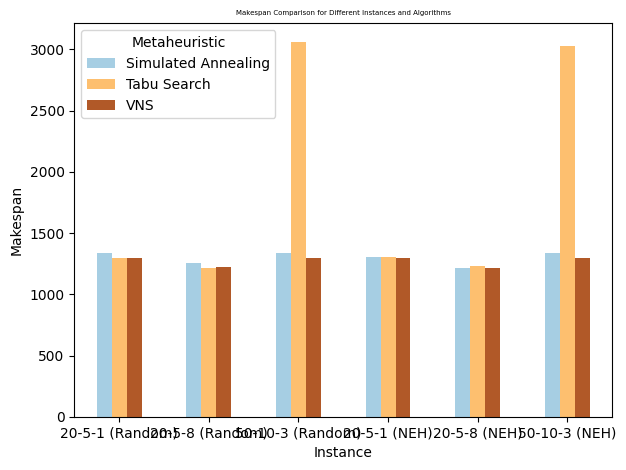

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(16,10))
df.plot(kind='bar', colormap='Paired');

# Set plot labels and title
plt.xlabel('Instance')
plt.ylabel('Makespan')
plt.title('Makespan Comparison for Different Instances and Algorithms', fontsize=5)
plt.xticks(rotation=0)
plt.savefig('pop_meta.png')
plt.tight_layout()
plt.show()

/var/folders/_z/zdw54df50fz9k671g3nvfjrc0000gn/T/ipykernel_12868/1264190801.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = plt.cm.get_cmap('tab20').colors


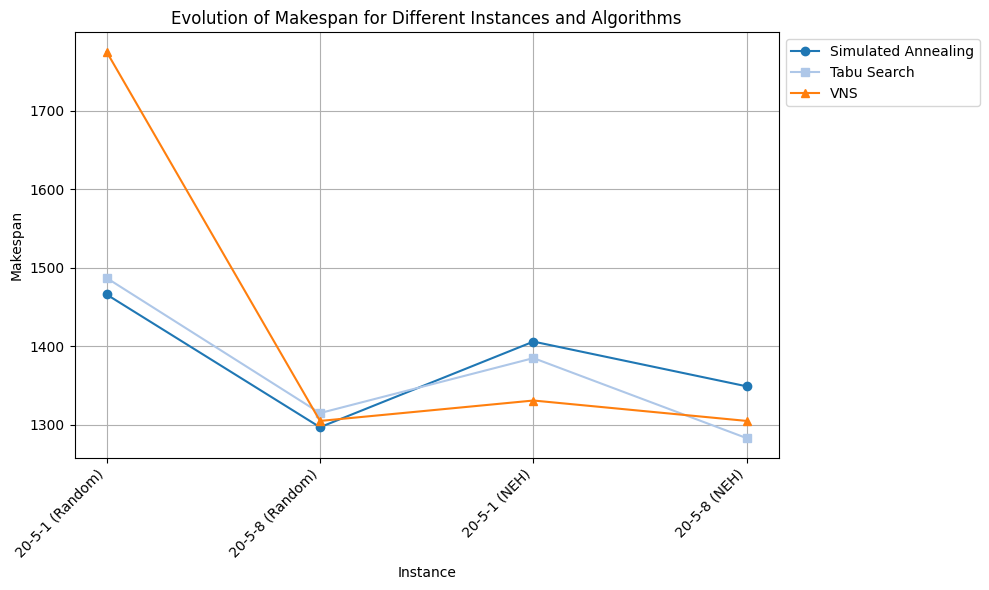

In [ ]:
import matplotlib.pyplot as plt

# Données à représenter
instances = ['20-5-1 (Random)', '20-5-8 (Random)', '20-5-1 (NEH)', '20-5-8 (NEH)']
algorithms = [ 'Simulated Annealing', 'Tabu Search', 'VNS']
makespan_data = [
    [1466.0, 1297.0, 1406.0, 1349.0],
    [1487.0, 1315.0, 1385.0, 1283.0],
    [1775.0, 1305.0, 1331.0, 1305.0],
    [1567.0, 1230.0, 1245.0, 1210.0]
]

# Création du graphique en ligne avec marqueurs
plt.figure(figsize=(10, 6))
markers = ['o', 's', '^', 'v', 'D', 'p', 'X']
colors = plt.cm.get_cmap('tab20').colors

for i, algorithm in enumerate(algorithms):
    plt.plot(instances, makespan_data[i], marker=markers[i], label=algorithm, color=colors[i])

# Paramètres du graphique
plt.xlabel('Instance')
plt.ylabel('Makespan')
plt.title('Evolution of Makespan for Different Instances and Algorithms')
plt.xticks(rotation=45, ha='right')
plt.legend(loc='upper left', bbox_to_anchor=(1,1))

# Affichage du graphique
plt.tight_layout()
plt.grid(True)
plt.show()


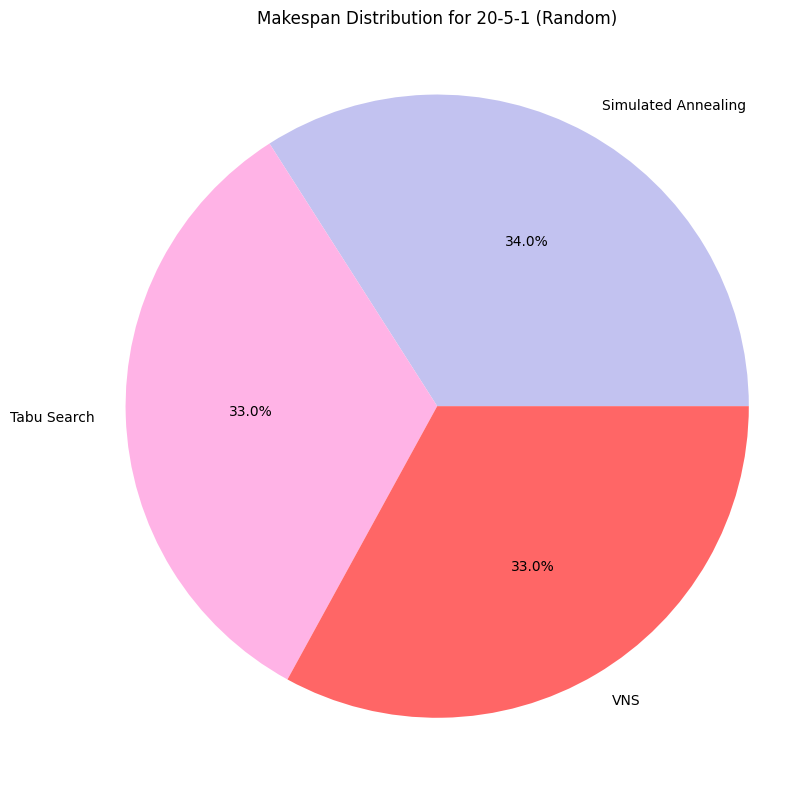

In [ ]:
import matplotlib.pyplot as plt

# Données à représenter
instance = '20-5-1 (Random)'
algorithms = ['Simulated Annealing', 'Tabu Search', 'VNS']
makespan_data = [ 1339.0,1297.0, 1297.0]

# Couleurs personnalisées pour chaque algorithme
colors = ['#c2c2f0', '#ffb3e6', '#ff6666']

# Création du graphique circulaire
plt.figure(figsize=(8, 8))
plt.pie(makespan_data, labels=algorithms, colors=colors, autopct='%1.1f%%')

# Paramètres du graphique
plt.title(f'Makespan Distribution for {instance}')
plt.axis('equal')  # Pour que le pie chart soit un cercle et non une ellipse

# Affichage du graphique
plt.tight_layout()
plt.show()

